# Phase 5: Dense Neural Network

In this phase, I will build a simple neural network using TensorFlow/Keras.

The main goals of this phase are:

- Load the MNIST dataset
- Preprocess the images
- Build a dense neural network
- Train the model
- Evaluate the model accuracy
- Compare the dense neural network with the Logistic Regression baseline model

In [6]:

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import plot_model

In [7]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [8]:
x_train_norm=x_train / 255.0
x_test_norm=x_test/255.0

In [9]:
print("Training data shape:", x_train_norm.shape)
print("Test data shape:", x_test_norm.shape)

print("Minimum pixel value:", x_train_norm.min())
print("Maximum pixel value:", x_train_norm.max())

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [10]:
model= Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

c:\Users\User\Desktop\handwritten-digit-recognition\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
history = model.fit(
    x_train_norm,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9181 - loss: 0.2839 - val_accuracy: 0.9538 - val_loss: 0.1548
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9628 - loss: 0.1255 - val_accuracy: 0.9661 - val_loss: 0.1189
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9744 - loss: 0.0868 - val_accuracy: 0.9709 - val_loss: 0.0937
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9810 - loss: 0.0635 - val_accuracy: 0.9689 - val_loss: 0.0955
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9847 - loss: 0.0498 - val_accuracy: 0.9745 - val_loss: 0.0871


In [16]:
test_loss, test_accuracy = model.evaluate(x_test_norm, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)
print("Test accuracy (%):", test_accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9765 - loss: 0.0827
Test loss: 0.08268367499113083
Test accuracy: 0.9764999747276306
Test accuracy (%): 97.64999747276306


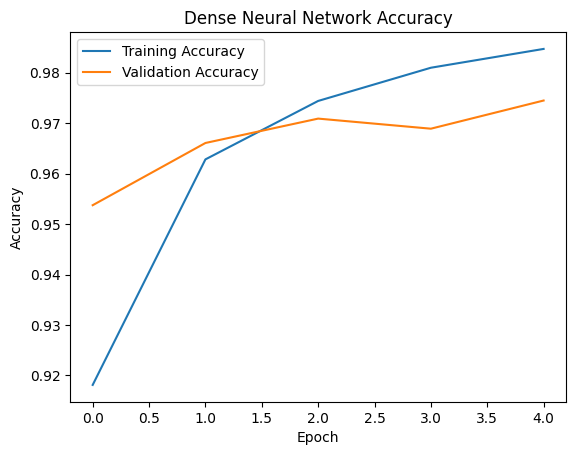

In [17]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Dense Neural Network Accuracy")
plt.legend()
plt.show()

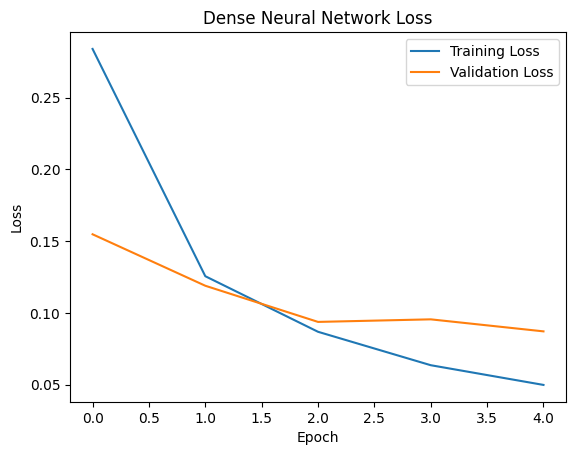

In [18]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Dense Neural Network Loss")
plt.legend()
plt.show()

In [19]:
y_prob = model.predict(x_test_norm)
y_pred = np.argmax(y_prob, axis=1)



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [20]:
print("First 10 true labels:")
print(y_test[:10])

print("First 10 predicted labels:")
print(y_pred[:10])


First 10 true labels:
[7 2 1 0 4 1 4 9 5 9]
First 10 predicted labels:
[7 2 1 0 4 1 4 9 6 9]


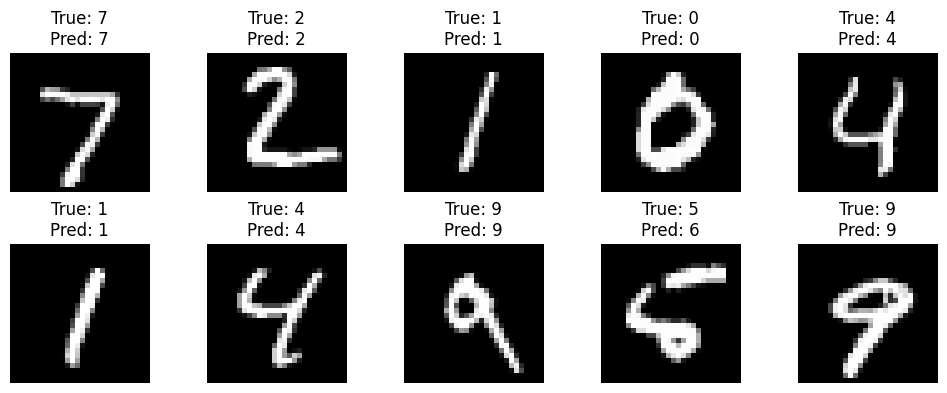

In [21]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"True: {y_test[i]}\nPred: {y_pred[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Dense Neural Network Predictions

The images above show the first 10 test examples from the MNIST dataset.

For each image:

- `True` represents the correct label from the dataset
- `Pred` represents the label predicted by the dense neural network

This visual check helps confirm whether the model is correctly recognizing handwritten digits.

## Phase 5 Summary: Dense Neural Network

In this phase, I built and trained a simple dense neural network using TensorFlow/Keras.

### Completed Tasks

- Loaded the MNIST dataset
- Normalized pixel values from 0–255 to 0–1
- Built a dense neural network using Keras
- Used a `Flatten` layer to convert each 28x28 image into 784 values
- Added a hidden dense layer with 128 neurons and ReLU activation
- Added an output layer with 10 neurons and softmax activation
- Compiled the model using:
  - Adam optimizer
  - Sparse categorical crossentropy loss
  - Accuracy metric
- Trained the model for 5 epochs
- Evaluated the model on the test set
- Plotted training and validation accuracy
- Plotted training and validation loss
- Made predictions on the test set
- Visualized sample predictions

### Key Observation

The dense neural network learns more complex patterns than the Logistic Regression baseline model.

The Logistic Regression model used flattened pixel values directly, while the dense neural network learned hidden representations through a hidden layer.

This model will later be compared with a Convolutional Neural Network to see whether convolutional layers improve handwritten digit recognition performance.